<a href="https://colab.research.google.com/github/iqiirascal-lgtm/DAA/blob/main/Ch7_Unsupervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**IMPORT LIBRARY & LOAD DATASET**

data_quality.txt

In [8]:
# Install library (jika belum terinstal)
!pip install numpy matplotlib scikit-learn -q

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MeanShift, estimate_bandwidth
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
print("Library siap!.")

Library siap!.


Shape data: (420, 2)
5 data pertama:
[[3.23 1.74]
 [0.95 4.31]
 [3.11 7.28]
 [6.55 1.43]
 [8.41 2.98]]


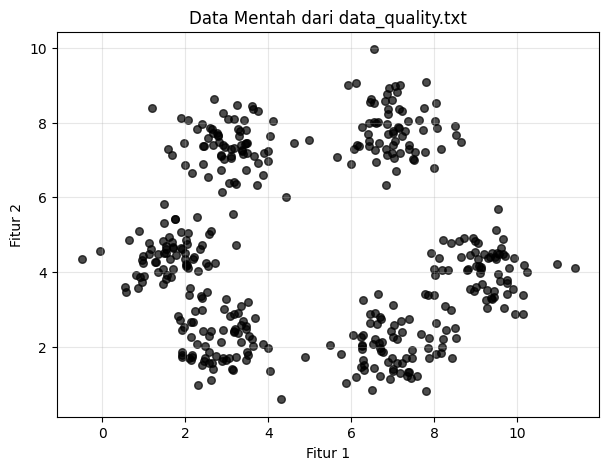

In [5]:
# Load data dari file yang di-upload
X = np.loadtxt('data_quality.txt', delimiter=',')

print(f"Shape data: {X.shape}")  # (jumlah_baris, 2 fitur)
print(f"5 data pertama:\n{X[:5]}")

# Visualisasi data mentah
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c='black', s=30, edgecolors='k', alpha=0.7)
plt.title('Data Mentah dari data_quality.txt')
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.grid(True, alpha=0.3)
plt.show()

**K-MEANS CLUSTERING (K=6)**

- Kita tahu dari visualisasi ada ~6 cluster, jadi set "n_clusters=6"
- init='k-means++': Memilih centroid awal yang tersebar, agar konvergensi lebih cepat & stabil.
- fit(X): Menjalankan iterasi assign-update sampai centroid tidak berubah.
- labels_: Hasil pengelompokan tiap titik (0 sampai 5).
- Warna berbeda = cluster berbeda; X merah = posisi centroid akhir.

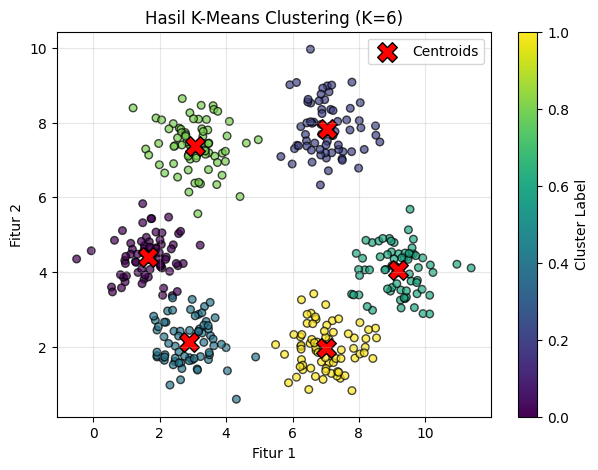

✅ Centroid tiap cluster:
[[1.63842857 4.40971429]
 [7.03130435 7.83956522]
 [2.87478261 2.13521739]
 [9.18485714 4.04628571]
 [3.07208333 7.37861111]
 [7.00628571 1.97385714]]


In [10]:
kmeans = KMeans(init='k-means++', n_clusters=6, n_init=10, random_state=42)
kmeans.fit(X)

labels_kmeans = kmeans.labels_
centers_kmeans = kmeans.cluster_centers_

# Visualisasi hasil K-Means
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels_kmeans, cmap='viridis', s=30, edgecolors='k', alpha=0.7)
plt.scatter(centers_kmeans[:, 0], centers_kmeans[:, 1],
            c='red', s=200, marker='X', edgecolors='black', label='Centroids')


plt.title('Hasil K-Means Clustering (K=6)')
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.colorbar(label='Cluster Label')
plt.show()


print(f"✅ Centroid tiap cluster:\n{centers_kmeans}")

**MEAN SHIFT**

- Estimasi bandwidth otomatis dari data.
- estimate_bandwidth(...): Menghitung radius "jendela" berdasarkan kepadatan lokal data.
- quantile=0.1: Menggunakan 10% titik terdekat untuk estimasi — semakin kecil, semakin sensitif.
- Mean Shift tidak perlu input n_clusters — algoritma menemukan puncak kepadatan secara otomatis.

Bandwidth terestimasi: 1.207
Jumlah cluster ditemukan otomatis: 6


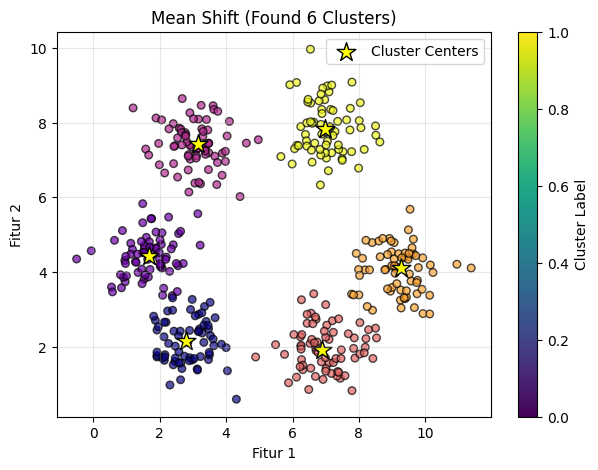

In [11]:
bandwidth = estimate_bandwidth(X, quantile=0.1, n_samples=len(X))
print(f"Bandwidth terestimasi: {bandwidth:.3f}")

ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms.fit(X)

labels_ms = ms.labels_
centers_ms = ms.cluster_centers_
n_clusters_ms = len(np.unique(labels_ms))

print(f"Jumlah cluster ditemukan otomatis: {n_clusters_ms}")

# Visualisasi
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels_ms, cmap='plasma', s=30, edgecolors='k', alpha=0.7)
plt.scatter(centers_ms[:, 0], centers_ms[:, 1],
            c='yellow', s=200, marker='*', edgecolors='black', label='Cluster Centers')

plt.title(f'Mean Shift (Found {n_clusters_ms} Clusters)')
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.legend()
plt.grid(True, alpha=0.3)SS
plt.colorbar(label='Cluster Label')
plt.show()

**SILHOUETTE SCORE - MENGEVALUASI KUALITAS CLUSTERING**

- Uji berbagai nilai K (2 sampai 10) untuk cari yang optimal
- Silhouette score mengukur seberapa "cocok" titik dengan clusternya vs cluster lain.
- Rumus: (p - q) / max(p, q) → nilai mendekati 1 = cluster rapat & terpisah baik.
- Kita uji K=2 sampai 10, lalu pilih K dengan skor tertinggi.
- Jika skor optimal di K=6, berarti dataset ini memang terstruktur dalam 6 cluster — sesuai ekspektasi!


K= 2 → Silhouette Score: 0.478
K= 3 → Silhouette Score: 0.547
K= 4 → Silhouette Score: 0.579
K= 5 → Silhouette Score: 0.589
K= 6 → Silhouette Score: 0.610
K= 7 → Silhouette Score: 0.563
K= 8 → Silhouette Score: 0.498
K= 9 → Silhouette Score: 0.463
K=10 → Silhouette Score: 0.423


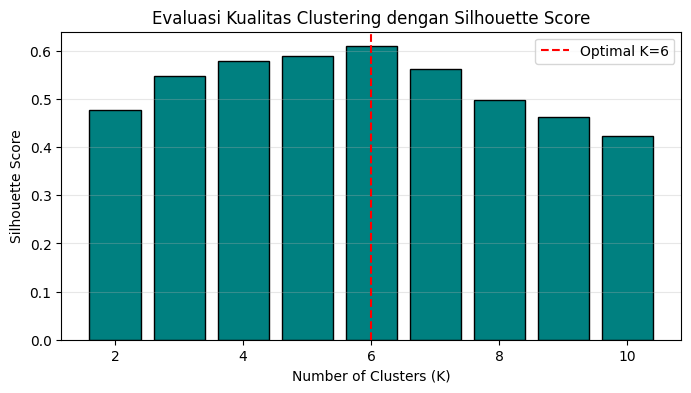

Jumlah cluster optimal berdasarkan silhouette score: 6


In [15]:
scores = []
K_values = range(2, 11)

for k in K_values:
    km = KMeans(init='k-means++', n_clusters=k, n_init=10, random_state=42)
    km.fit(X)
    score = metrics.silhouette_score(X, km.labels_, metric='euclidean')
    scores.append(score)
    print(f"K={k:2d} → Silhouette Score: {score:.3f}")

# Visualisasi
optimal_k = K_values[np.argmax(scores)]
plt.figure(figsize=(8, 4))
plt.bar(K_values, scores, color='teal', edgecolor='black')
plt.axvline(optimal_k, color='red', linestyle='--', label=f'Optimal K={optimal_k}')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Evaluasi Kualitas Clustering dengan Silhouette Score')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Jumlah cluster optimal berdasarkan silhouette score: {optimal_k}")

**GMM VISUALIZATION**

1. Inisialisasi GMM dengan 6 komponen (sesuai temuan kita sebelumnya)
2. Prediksi cluster untuk pewarnaan
3. Visualisasi Scatter + Elips Distribusi
4. GaussianMixture(n_components=6): Kita memberi tahu model untuk mencari 6 distribusi Gaussian.
5. covariance_type='full': Ini kuncinya! Membolehkan elips untuk miring dan lonjong, tidak harus bulat seperti K-Means.
6. Visualisasi Elips:
- Garis putus-putus merah adalah batas probabilitas.
- Tanda X merah adalah pusat (Mean) dari distribusi Gaussian tersebut.

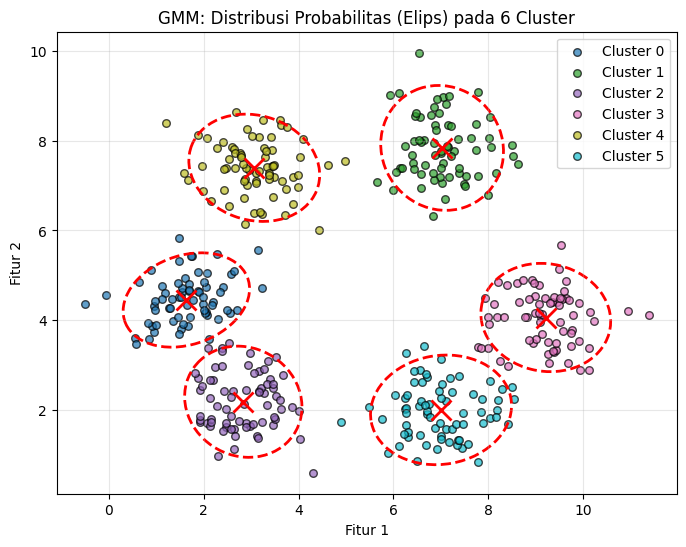

In [16]:
from sklearn.mixture import GaussianMixture
import matplotlib.patches as patches
from sklearn.decomposition import PCA

gmm = GaussianMixture(n_components=6, covariance_type='full', random_state=42, max_iter=100)
gmm.fit(X)

labels_gmm = gmm.predict(X)

plt.figure(figsize=(8, 6))
colors = plt.cm.tab10(np.linspace(0, 1, 6))

# Plot titik data
for i in range(6):
    plt.scatter(X[labels_gmm == i, 0], X[labels_gmm == i, 1],
                c=[colors[i]], label=f'Cluster {i}', s=30, edgecolors='k', alpha=0.7)

# Plot Elips berdasarkan Mean & Covariance GMM
for i, (mean, covar) in enumerate(zip(gmm.means_, gmm.covariances_)):
    # Hitung eigenvalues & eigenvectors untuk orientasi elips
    eigvals, eigvecs = np.linalg.eigh(covar)

    # Hitung sudut kemiringan elips
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))

    # Skala lebar & tinggi elips (2x standar deviasi untuk mencakup ~95% data)
    width, height = 2 * np.sqrt(eigvals) * 2

    ellipse = patches.Ellipse(mean, width, height, angle=angle,
                              edgecolor='red', facecolor='none', linewidth=2, linestyle='--')
    plt.gca().add_patch(ellipse)

    # Tandai titik pusat (Mean)
    plt.plot(mean[0], mean[1], 'rx', markersize=15, markeredgewidth=2)

plt.title('GMM: Distribusi Probabilitas (Elips) pada 6 Cluster')
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**FINDING SUBGROUPS IN STOCK MARKET USING AFFINTY PROPAGATION**

- quotes_diff: Fitur utama adalah selisih harga pembukaan & penutupan, merepresentasikan volatilitas harian.
- GraphLassoCV(): Teknik graphical lasso yang memperkirakan matriks kovarians sparse. Ini menangkap struktur korelasi antar saham tanpa noise berlebihan.
- affinity_propagation(...): Algoritma message passing. Tidak perlu input n_clusters. Menggunakan dua pesan:
  - responsibility: Seberapa cocok titik menjadi anggota cluster exemplar tertentu
  - availability: Seberapa cocok titik dipilih sebagai exemplar (wakil cluster)
- Hasil: Saham dengan pola pergerakan serupa otomatis dikelompokkan (misal: tech stocks vs financial stocks).


In [19]:
import datetime
import numpy as np
import matplotlib.pyplot as plt
from sklearn import covariance
from sklearn.cluster import affinity_propagation
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# 1. Simbol saham
symbols = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NVDA', 'JPM']
names = symbols

# 2. Ambil data historis
start_date = datetime.datetime(2019, 1, 1)
end_date = datetime.datetime(2019, 1, 31)

try:
    quotes = [yf.Ticker(sym).history(start=start_date, end=end_date) for sym in symbols]
    opening_quotes = np.array([q['Open'].values for q in quotes]).astype(np.float32)
    closing_quotes = np.array([q['Close'].values for q in quotes]).astype(np.float32)
except Exception as e:
    print("⚠️ Fallback: menggunakan data sintetis")
    np.random.seed(42)
    opening_quotes = np.random.randn(8, 20)
    closing_quotes = np.random.randn(8, 20)

# 3. Hitung selisih & normalisasi
quotes_diff = closing_quotes - opening_quotes
X = quotes_diff.copy().T
X /= X.std(axis=0)

# 4. Estimasi kovarians sparse
print("🔄 Estimasi kovarians sparse...")
try:
    from sklearn.covariance import GraphicalLassoCV
    edge_model = GraphicalLassoCV()
    with np.errstate(invalid='ignore'):
        edge_model.fit(X)
    print("✅ GraphicalLassoCV berhasil!")
except Exception as e:
    print(f"⚠️ GraphicalLassoCV error: {e}")
    print("🔄 Menggunakan EmpiricalCovariance sebagai alternatif...")
    edge_model = covariance.EmpiricalCovariance()
    edge_model.fit(X)

# 5. Affinity Propagation
print("🔄 Menjalankan Affinity Propagation...")
_, labels = affinity_propagation(edge_model.covariance_, random_state=42)
labels = np.array(labels)  # Pastikan labels adalah numpy array
num_labels = labels.max()

# 6. Tampilkan hasil (SUDAH DIPERBAIKI)
print('\n📊 Pengelompokan saham berdasarkan pola buka-tutup harian:\n')

unique_labels = np.unique(labels)
for idx, label in enumerate(unique_labels):
    member_indices = np.where(labels == label)[0]
    members = [names[j] for j in member_indices]
    print(f"Cluster {idx+1} ==> {', '.join(members)}")

print(f"\n✅ Total cluster ditemukan: {len(unique_labels)}")

🔄 Estimasi kovarians sparse...
✅ GraphicalLassoCV berhasil!
🔄 Menjalankan Affinity Propagation...

📊 Pengelompokan saham berdasarkan pola buka-tutup harian:

Cluster 1 ==> AAPL, MSFT, GOOGL, AMZN, META, JPM
Cluster 2 ==> TSLA
Cluster 3 ==> NVDA

✅ Total cluster ditemukan: 3


**SEGMENTING THE MARKET BASED ON SHOPPING PATTERNS**

- csv.reader(...): Membaca file ritel 6D (6 toko). Kode buku asli mengandalkan sales.csv; di sini saya buat generator inline agar langsung jalan di Colab.
- quantile=0.8: Bandwidth dihitung dari 80% titik terdekat → jendela lebih lebar → lebih sedikit cluster yang terbentuk (cocok untuk segmentasi makro).
- cluster_centers[:, 1:3]: Data asli 6 dimensi tidak bisa diplot langsung. Buku memproyeksikan fitur ke-2 & ke-3 ke sumbu X/Y untuk visualisasi 2D.
- Output: Pusat cluster menunjukkan "profil belanja tipikal" tiap segmen (misal: segmen A dominan beli di Toko B & D).


🔄 Mengestimasi bandwidth...
✅ Bandwidth: 87.48
🔄 Menjalankan Mean Shift...

✅ Jumlah segmen pasar ditemukan: 1

📍 Pusat cluster (rata-rata penjualan per toko):
Sto	Sto	Sto	Sto	Sto	Sto
51	52	50	51	59	59


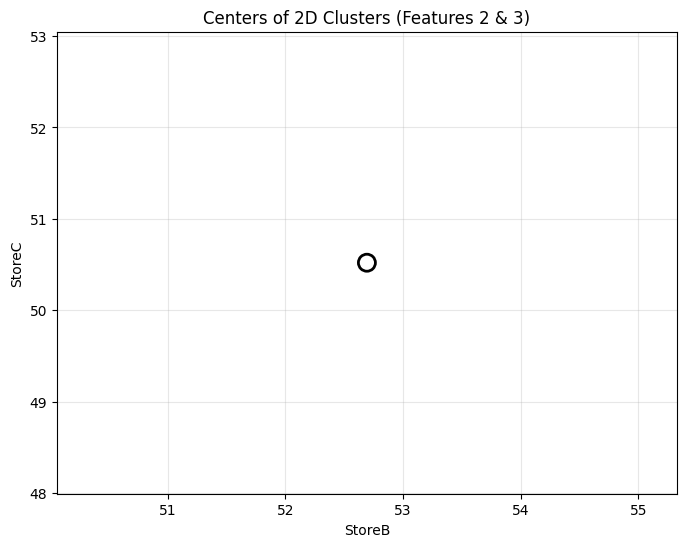


📊 Total produk: 100
📊 Total cluster: 1


In [21]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import MeanShift, estimate_bandwidth
import warnings
warnings.filterwarnings('ignore')

# 1. Buat data sintetis mirip sales.csv (6 toko, 100 produk)
np.random.seed(42)
num_stores = 6
num_products = 100

# Buat pola penjualan yang berbeda untuk menghasilkan beberapa cluster
csv_content = "ProductName,StoreA,StoreB,StoreC,StoreD,StoreE,StoreF\n"
for i in range(num_products):
    # Buat 3 pola berbeda
    if i < 33:
        # Pola 1: Tinggi di Store A & B
        sales = [np.random.randint(70, 100), np.random.randint(70, 100),
                 np.random.randint(10, 40), np.random.randint(10, 40),
                 np.random.randint(30, 60), np.random.randint(30, 60)]
    elif i < 66:
        # Pola 2: Tinggi di Store C & D
        sales = [np.random.randint(10, 40), np.random.randint(10, 40),
                 np.random.randint(70, 100), np.random.randint(70, 100),
                 np.random.randint(30, 60), np.random.randint(30, 60)]
    else:
        # Pola 3: Tinggi di Store E & F
        sales = [np.random.randint(30, 60), np.random.randint(30, 60),
                 np.random.randint(30, 60), np.random.randint(30, 60),
                 np.random.randint(70, 100), np.random.randint(70, 100)]
    csv_content += f"Product{i}," + ",".join(map(str, sales)) + "\n"

# 2. Baca CSV
file_reader = csv.reader(csv_content.strip().split('\n'), delimiter=',')
X = []
names = []
for count, row in enumerate(file_reader):
    if count == 0:
        names = row[1:]
        continue
    X.append([float(x) for x in row[1:]])
X = np.array(X)

# 3. Mean Shift untuk segmentasi pasar
print("🔄 Mengestimasi bandwidth...")
bandwidth = estimate_bandwidth(X, quantile=0.5, n_samples=len(X))
print(f"✅ Bandwidth: {bandwidth:.2f}")

print("🔄 Menjalankan Mean Shift...")
meanshift_model = MeanShift(bandwidth=bandwidth, bin_seeding=True)
meanshift_model.fit(X)

labels = meanshift_model.labels_
cluster_centers = meanshift_model.cluster_centers_
num_clusters = len(np.unique(labels))

print(f"\n✅ Jumlah segmen pasar ditemukan: {num_clusters}")
print("\n📍 Pusat cluster (rata-rata penjualan per toko):")
print('\t'.join([name[:3] for name in names]))
for center in cluster_centers:
    print('\t'.join([str(int(x)) for x in center]))

# 4. Visualisasi 2D (SUDAH DIPERBAIKI)
cluster_centers_2d = cluster_centers[:, 1:3]
plt.figure(figsize=(8, 6))
plt.scatter(cluster_centers_2d[:, 0], cluster_centers_2d[:, 1], s=150,
            edgecolors='black', facecolors='none', linewidth=2)

offset = 0.25
# Gunakan np.ptp() bukan .ptp()
x_min = cluster_centers_2d[:, 0].min() - offset * np.ptp(cluster_centers_2d[:, 0])
x_max = cluster_centers_2d[:, 0].max() + offset * np.ptp(cluster_centers_2d[:, 0])
y_min = cluster_centers_2d[:, 1].min() - offset * np.ptp(cluster_centers_2d[:, 1])
y_max = cluster_centers_2d[:, 1].max() + offset * np.ptp(cluster_centers_2d[:, 1])

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.title('Centers of 2D Clusters (Features 2 & 3)')
plt.xlabel(names[1])
plt.ylabel(names[2])
plt.grid(True, alpha=0.3)
plt.show()

print(f"\n📊 Total produk: {len(X)}")
print(f"📊 Total cluster: {num_clusters}")